In [1]:
from typing import Dict, List, Any
from numpy.typing import NDArray

from model_ranking import (
    get_summary_results, 
    per_source_model_results,
    cmb_consistency_score_weighted_average,
    to_target_transfer_correlations_with_norm,
    correlation_table,
    per_target_consis_result_type,
    per_target_performance_result_type,
)
from model_ranking import plot_alpha_sweep_specific_norm

INFO: P [MainThread] 2025-10-30 11:01:25,900 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NA_UNet_source_models_epoch1 = {
    "VNC": "VtoH_def_V_model_NA2/epoch-1",
}
NA_UNet_source_models_epoch2 = {
    "VNC": "VtoH_def_V_model_NA2/epoch-2",
}
NA_UNet_source_models_epoch3 = {
    "VNC": "VtoH_def_V_model_NA2/epoch-3",
}
NA_UNet_source_models_epoch4 = {
    "VNC": "VtoH_def_V_model_NA2/epoch-4",
}
NA_UNet_source_models_epoch5 = {
    "VNC": "VtoH_def_V_model_NA2/epoch-5",
}

UNet_source_models_epoch1 = {
    "Hmito": "HtoR_def_Hm_model4/epoch-1",
}
UNet_source_models_epoch2 = {
    "Hmito": "HtoR_def_Hm_model4/epoch-2",
}
UNet_source_models_epoch3 = {
    "Hmito": "HtoR_def_Hm_model4/epoch-3",
}
UNet_source_models_epoch4 = {
    "Hmito": "HtoR_def_Hm_model4/epoch-4",
}
UNet_source_models_epoch5 = {
    "Hmito": "HtoR_def_Hm_model4/epoch-5",
}


Res_source_models_epoch1 = {
    "Hmito": "HtoR_def_Hm_model_Res1/epoch-1",
    "VNC": "VtoH_def_V_model_Res1/epoch-1",
}
Res_source_models_epoch2 = {
    "Hmito": "HtoR_def_Hm_model_Res1/epoch-2",
    "VNC": "VtoH_def_V_model_Res1/epoch-2",
}
Res_source_models_epoch3 = {
    "Hmito": "HtoR_def_Hm_model_Res1/epoch-3",
    "VNC": "VtoH_def_V_model_Res1/epoch-3",
}
Res_source_models_epoch4 = {
    "Hmito": "HtoR_def_Hm_model_Res1/epoch-4",
    "VNC": "VtoH_def_V_model_Res1/epoch-4",
}
Res_source_models_epoch5 = {
    "Hmito": "HtoR_def_Hm_model_Res1/epoch-5",
    "VNC": "VtoH_def_V_model_Res1/epoch-5",
}



consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
consis_keys_bckg = {
    "EPFL": "EI_consis_bckg",
    "Hmito": "EI_consis_bckg",
    "Rmito": "EI_consis_bckg",
    "VNC": "EI_consis_bckg",
}
result_folders={
    "Hmito": "finetuned_stepwise",
    "Rmito": "finetuned_stepwise",
    # "Hmito": "P_full",
    # "Rmito": "P_full",
    # "VNC": "P_full",
}

per_target_norms: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}

perf_key = "F1_eval"
approach="consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

# VtoH_def_V_model_NA2 StepWise Finetuning

In [52]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"],
    #"gauss": ["a001-003", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"],
}
#targets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["Hmito"]
#source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models, Unetr_source_models]
source_model_types = [
    NA_UNet_source_models_epoch1, 
    NA_UNet_source_models_epoch2, 
    NA_UNet_source_models_epoch3, 
    NA_UNet_source_models_epoch4, 
    NA_UNet_source_models_epoch5,
]

In [53]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["Hmito", "Rmito"]
    else:
        sources = ["VNC"]
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        # if "Unetr" in model_type["VNC"]:
        #     sources = ["Hmito", "Rmito"] 
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 19.78it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 22.08it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 22.51it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 23.41it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 21.90it/s]


In [54]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["Hmito", "Rmito"]
    else:
        sources = ["VNC"]
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    for model_type in source_model_types:
        # if "Unetr" in model_type["EPFL"]:
        #     sources = ["EPFL", "Hmito", "Rmito"]

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_bckg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_bckg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
        
    
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: VNC


100%|██████████| 1/1 [00:00<00:00, 22.69it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 22.79it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 23.77it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 21.20it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 21.35it/s]


### Foreground Only consistency correlation

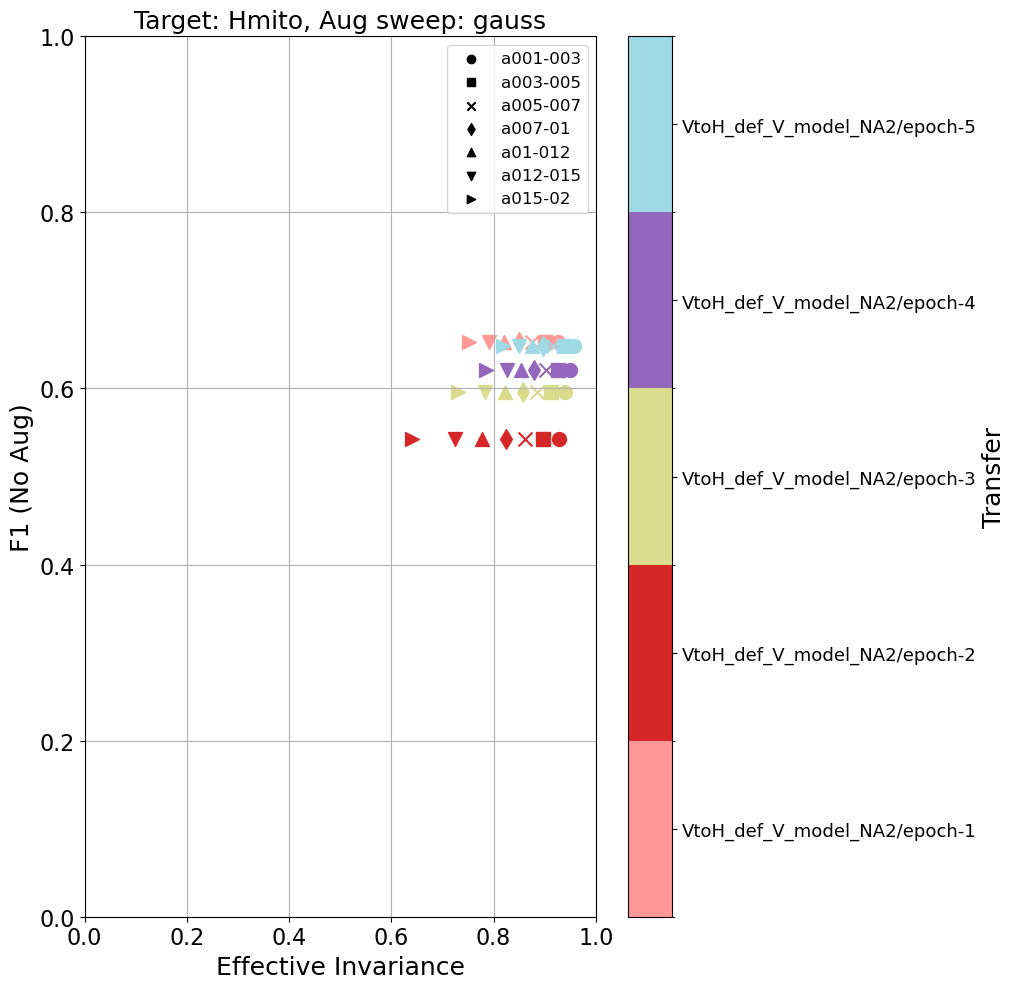

In [55]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [56]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"Gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

Gauss: a001-003
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.2     0.87    0.0         1.0  0.43     0.47
Gauss: a003-005
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4     0.51    0.4        0.47  0.53     0.35
Gauss: a005-007
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4      0.5    0.4        0.54  0.64     0.25
Gauss: a007-01
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4     0.49    0.4        0.52  0.71     0.18
Gauss: a01-012
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4     0.51    0.4         0.5  0.78     0.12
Gauss: 

In [57]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_Normalize']
        else:
            per_target_performance[target][model] = performance

In [ ]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/EI_consis/FORG"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['gauss']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_forg_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

#     with open(os.path.join(save_path, f"transfer_gauss_{alpha}_FORG_EI_scores.json"), "w") as f:
#         results: Dict[str, Any] = {
#             "transfer_scores": convert_numpy_types(per_target_consistency),
#         }
#         json.dump(results, f, indent=4)

# with open(os.path.join(save_path, f"transfer_performance_F1_scores.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_performance),
#     }
#     json.dump(results, f, indent=4)

In [59]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
    perturbation_key="gauss",
)

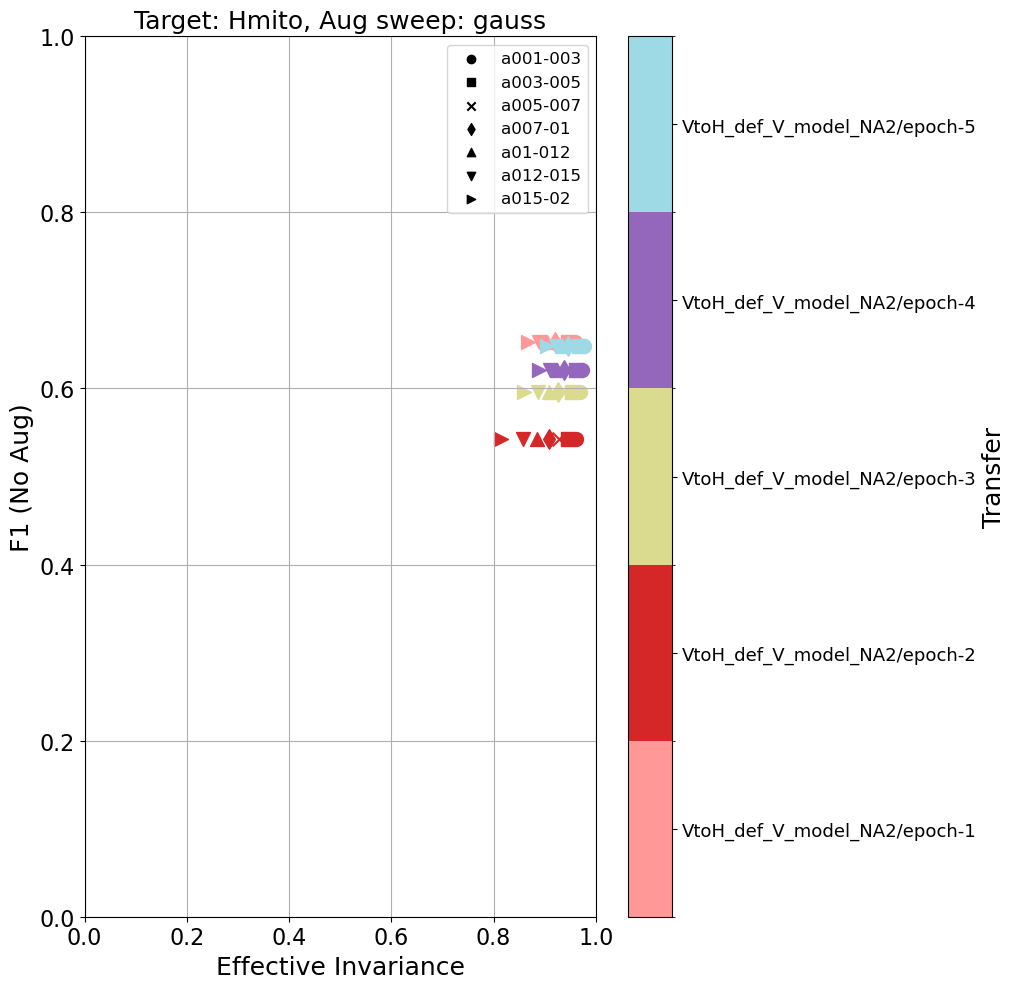

In [60]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )


In [61]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_cmb_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"Gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

Gauss: a001-003
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.2     0.81    0.0         1.0  0.36     0.55
Gauss: a003-005
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4      0.5    0.4        0.57  0.47     0.42
Gauss: a005-007
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4     0.51    0.4        0.58  0.58     0.31
Gauss: a007-01
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4      0.5    0.4        0.53  0.67     0.22
Gauss: a01-012
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4     0.47    0.4        0.49  0.74     0.15
Gauss: 

In [62]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/EI_consis/CMB"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['gauss']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_cmb_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

    with open(os.path.join(save_path, f"transfer_gauss_{alpha}_CMB_05f_05b_EI_scores.json"), "w") as f:
        results: Dict[str, Any] = {
            "transfer_scores": convert_numpy_types(per_target_consistency),
        }
        json.dump(results, f, indent=4)

# with open(os.path.join(save_path, f"transfer_performance_F1_scores.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_performance),
#     }
#     json.dump(results, f, indent=4)

# VtoH_def_V_model_Res1

In [36]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"],
    #"gauss": ["a001-003", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"],
}
#targets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["Hmito"]
#source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models, Unetr_source_models]
source_model_types = [
    Res_source_models_epoch1, 
    Res_source_models_epoch2, 
    Res_source_models_epoch3,
    Res_source_models_epoch4,
    Res_source_models_epoch5,
]

In [37]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["Hmito", "Rmito"]
    else:
        sources = ["VNC"]
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        # if "Unetr" in model_type["VNC"]:
        #     sources = ["Hmito", "Rmito"] 
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 16.14it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 21.87it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 20.39it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 20.94it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 20.08it/s]


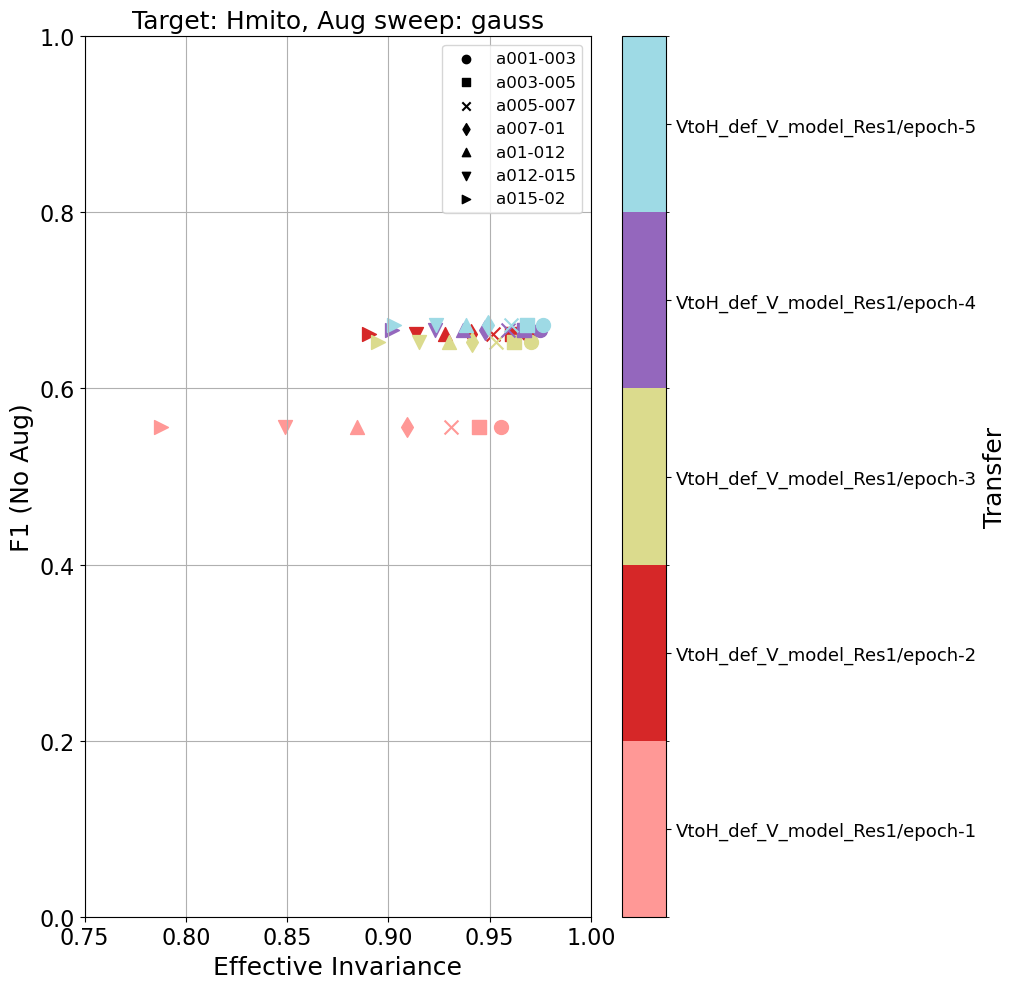

In [38]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0.75, 1),
        n_rows=1,
        n_cols = 1,
    )

In [39]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"Gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

Gauss: a001-003
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.08    0.9        0.08  0.96     0.01
Gauss: a003-005
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8      0.1    0.9        0.09  0.97     0.01
Gauss: a005-007
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8      0.1    0.9        0.07  0.98      0.0
Gauss: a007-01
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.07    0.9        0.09  0.99      0.0
Gauss: a01-012
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8      0.1    0.9        0.07  0.99      0.0
Gauss: 

In [40]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/EI_consis/FORG"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['gauss']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_forg_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

    with open(os.path.join(save_path, f"transfer_gauss_{alpha}_FORG_EI_scores.json"), "w") as f:
        results: Dict[str, Any] = {
            "transfer_scores": convert_numpy_types(per_target_consistency),
        }
        json.dump(results, f, indent=4)

# with open(os.path.join(save_path, f"transfer_performance_F1_scores.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_performance),
#     }
#     json.dump(results, f, indent=4)

In [41]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["Hmito", "Rmito"]
    else:
        sources = ["VNC"]
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    for model_type in source_model_types:
        # if "Unetr" in model_type["EPFL"]:
        #     sources = ["EPFL", "Hmito", "Rmito"]

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_bckg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_bckg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
        
    
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: VNC


100%|██████████| 1/1 [00:00<00:00, 19.91it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 23.05it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 22.80it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 24.56it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 14.70it/s]


In [42]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
    perturbation_key="gauss",
)

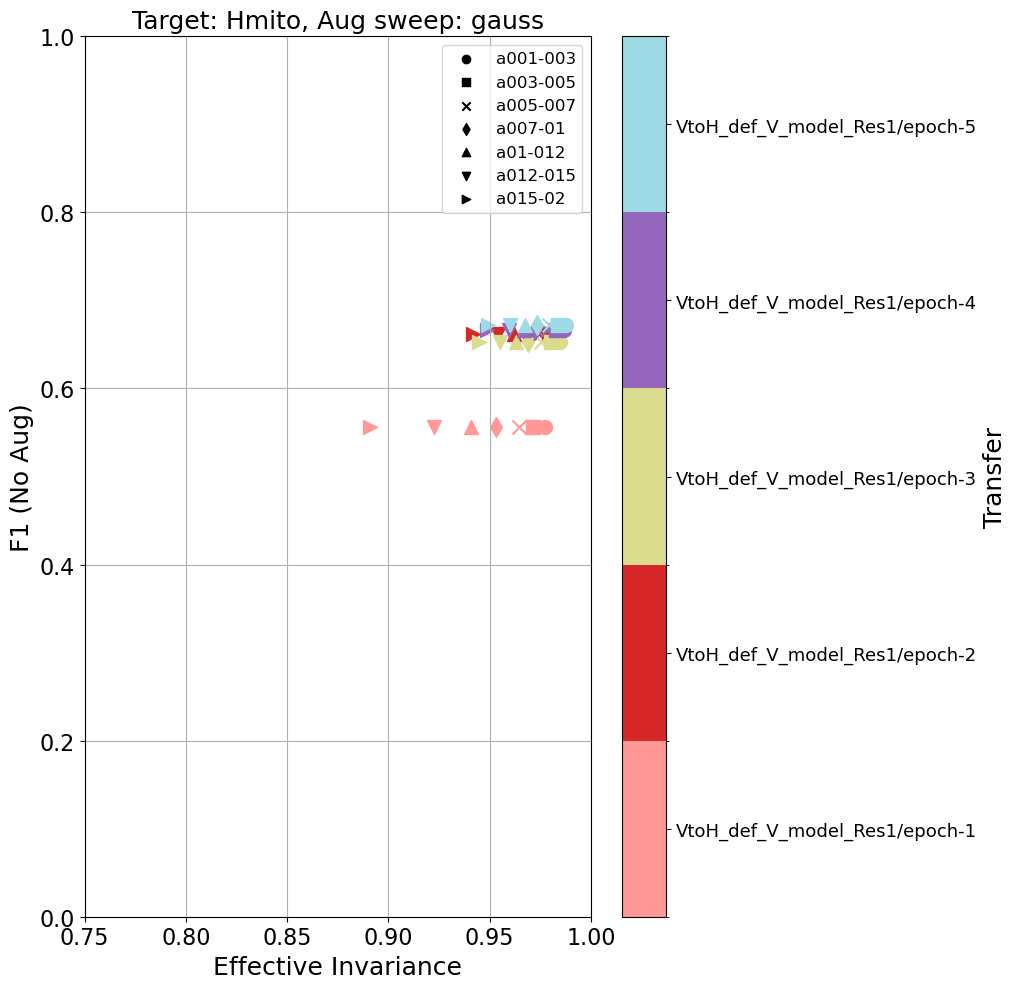

In [43]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0.75, 1),
        n_rows=1,
        n_cols = 1,
    )

In [44]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_cmb_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"Gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

Gauss: a001-003
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.08    0.9        0.07  0.95     0.01
Gauss: a003-005
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8      0.1    0.9        0.09  0.96     0.01
Gauss: a005-007
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.09    0.9        0.09  0.97     0.01
Gauss: a007-01
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.12    0.9        0.09  0.99      0.0
Gauss: a01-012
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.09    0.9        0.09  0.99      0.0
Gauss: 

## Save Results

In [45]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_Normalize']
        else:
            per_target_performance[target][model] = performance

In [46]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/EI_consis/CMB"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['gauss']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_cmb_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

    with open(os.path.join(save_path, f"transfer_gauss_{alpha}_CMB_05f_05b_EI_scores.json"), "w") as f:
        results: Dict[str, Any] = {
            "transfer_scores": convert_numpy_types(per_target_consistency),
        }
        json.dump(results, f, indent=4)

# with open(os.path.join(save_path, f"transfer_performance_F1_scores.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_performance),
#     }
#     json.dump(results, f, indent=4)

# HtoR_def_Hm_model_Res1 Stepwise Finetuning

In [24]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"],
    #"gauss": ["a001-003", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"],
}
#targets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["Rmito"]
#source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models, Unetr_source_models]
source_model_types = [
    Res_source_models_epoch1, 
    Res_source_models_epoch2, 
    Res_source_models_epoch3,
    Res_source_models_epoch4,
    Res_source_models_epoch5,
]

In [25]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["Hmito", "Rmito"]
    else:
        sources = ["Hmito"]
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        # if "Unetr" in model_type["VNC"]:
        #     sources = ["Hmito", "Rmito"] 
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 19.37it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 14.57it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 17.10it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 19.47it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 20.27it/s]


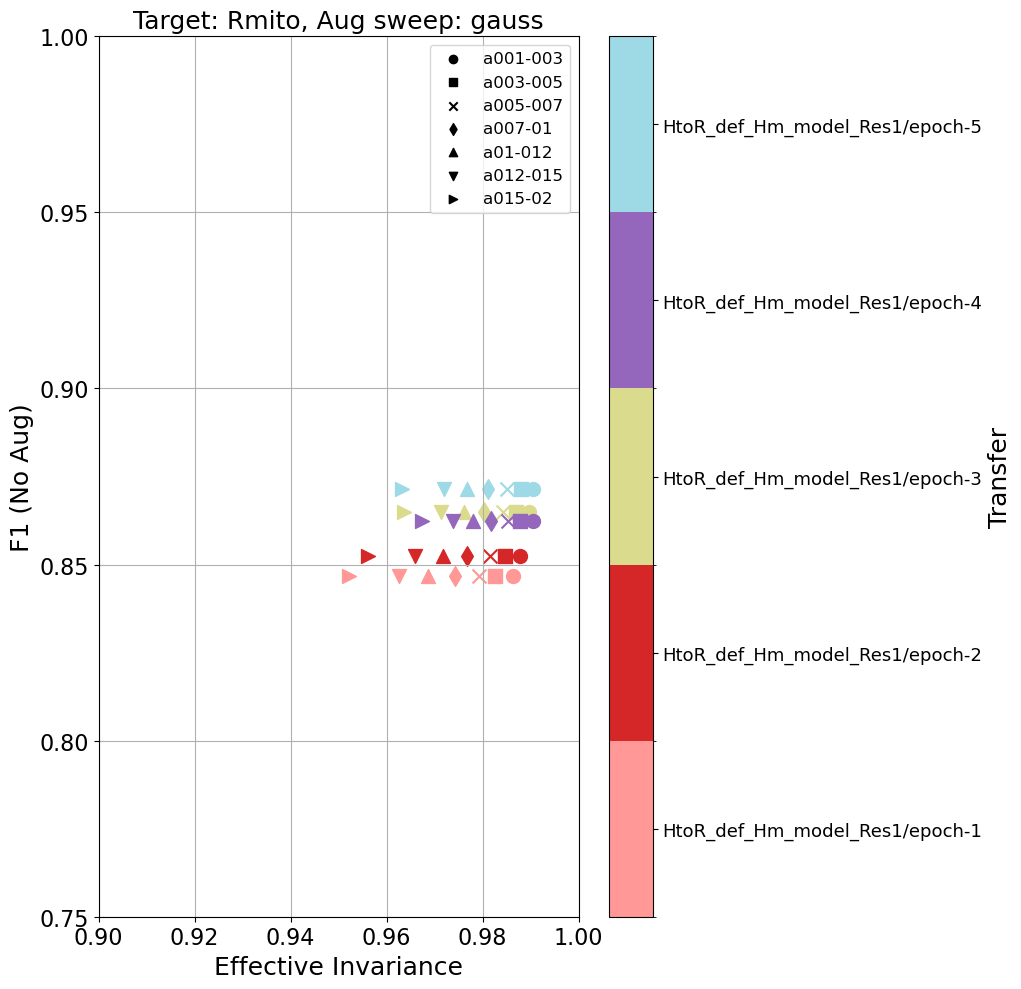

In [26]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0.9, 1),
        ylim=(0.75, 1),
        n_rows=1,
        n_cols = 1,
    )

In [27]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"Gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

Gauss: a001-003
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.24    0.7        0.25  0.94     0.02
Gauss: a003-005
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.8      0.1    0.9         0.1  0.94     0.02
Gauss: a005-007
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.22    0.7        0.21  0.93     0.02
Gauss: a007-01
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.22    0.7        0.22  0.91     0.03
Gauss: a01-012
               kt  kt pval  s rho  s rho pval   pr  pr pval
Task targets                                               
Mito Rmito    0.6     0.24    0.7        0.23  0.9     0.04
Gauss: a01

In [28]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/EI_consis/FORG"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['gauss']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_forg_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

    with open(os.path.join(save_path, f"transfer_gauss_{alpha}_FORG_EI_scores.json"), "w") as f:
        results: Dict[str, Any] = {
            "transfer_scores": convert_numpy_types(per_target_consistency),
        }
        json.dump(results, f, indent=4)

# with open(os.path.join(save_path, f"transfer_performance_F1_scores.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_performance),
#     }
#     json.dump(results, f, indent=4)

In [29]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["Hmito", "Rmito"]
    else:
        sources = ["Hmito"]
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    for model_type in source_model_types:
        # if "Unetr" in model_type["EPFL"]:
        #     sources = ["EPFL", "Hmito", "Rmito"]

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_bckg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_bckg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
        
    
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 22.13it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 21.23it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 22.90it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 25.19it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 21.25it/s]


In [30]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
    perturbation_key="gauss",
)

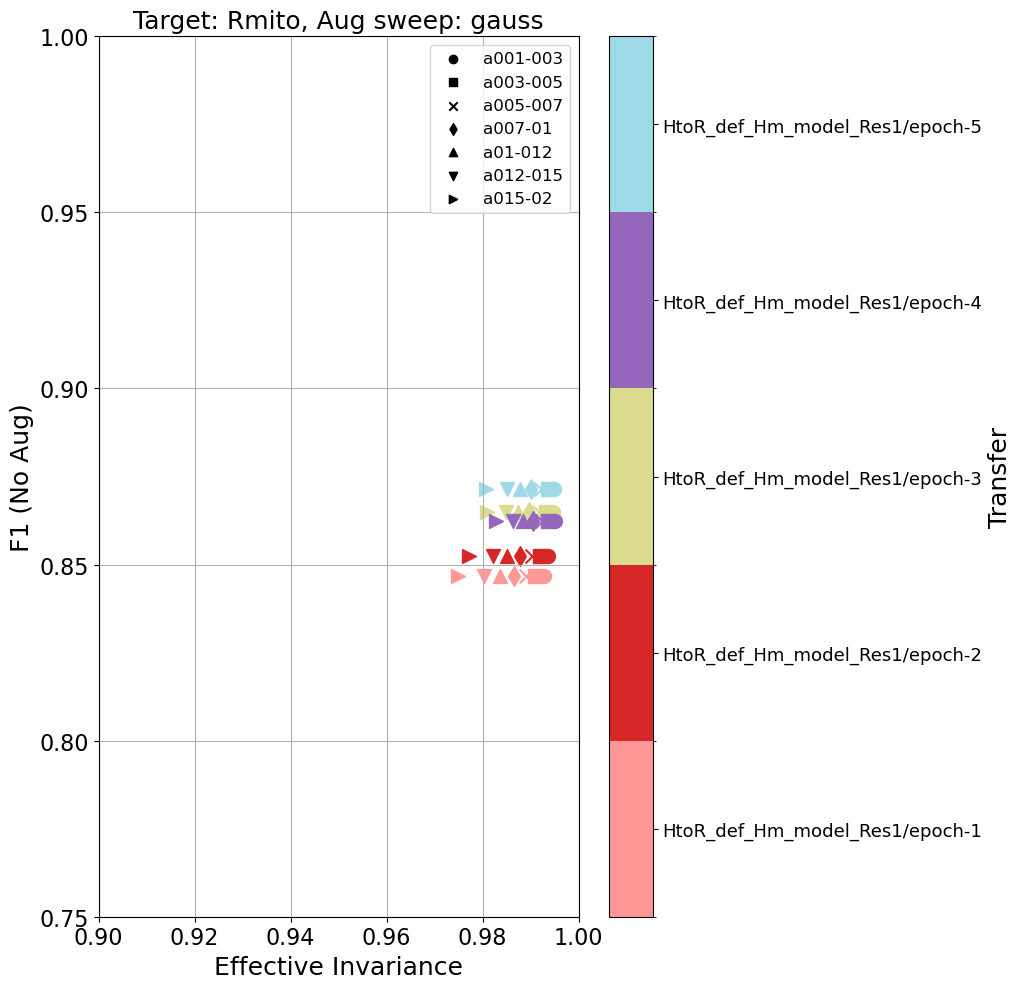

In [31]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0.9, 1),
        ylim=(0.75, 1),
        n_rows=1,
        n_cols = 1,
    )


In [32]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_cmb_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"Gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

Gauss: a001-003
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.23    0.7        0.26  0.93     0.02
Gauss: a003-005
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.25    0.7        0.25  0.94     0.02
Gauss: a005-007
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6      0.2    0.7        0.26  0.92     0.03
Gauss: a007-01
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.23    0.7        0.23  0.91     0.03
Gauss: a01-012
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.23    0.7        0.21  0.89     0.04
Gauss: 

## Save Results

In [33]:
per_target_forg_performance

{'Rmito': {'HtoR_def_Hm_model_Res1/epoch-1': {'norm_Normalize': 0.8468323945999146},
  'HtoR_def_Hm_model_Res1/epoch-2': {'norm_Normalize': 0.8523893356323242},
  'HtoR_def_Hm_model_Res1/epoch-3': {'norm_Normalize': 0.8648694753646851},
  'HtoR_def_Hm_model_Res1/epoch-4': {'norm_Normalize': 0.8622684478759766},
  'HtoR_def_Hm_model_Res1/epoch-5': {'norm_Normalize': 0.8714256286621094}}}

In [34]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_Normalize']
        else:
            per_target_performance[target][model] = performance

In [35]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/EI_consis/CMB"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['gauss']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_cmb_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

    with open(os.path.join(save_path, f"transfer_gauss_{alpha}_CMB_05f_05b_EI_scores.json"), "w") as f:
        results: Dict[str, Any] = {
            "transfer_scores": convert_numpy_types(per_target_consistency),
        }
        json.dump(results, f, indent=4)

# with open(os.path.join(save_path, f"transfer_performance_F1_scores.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_performance),
#     }
#     json.dump(results, f, indent=4)

# HtoR_def_Hm_model4 Stepwise Finetuning

In [28]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"],
    #"gauss": ["a001-003", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"],
}
#targets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["Rmito"]
#source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models, Unetr_source_models]
source_model_types = [
    UNet_source_models_epoch1, 
    UNet_source_models_epoch2, 
    UNet_source_models_epoch3,
    UNet_source_models_epoch4,
    UNet_source_models_epoch5,
]

In [29]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["Hmito", "Rmito"]
    else:
        sources = ["Hmito"]
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        # if "Unetr" in model_type["VNC"]:
        #     sources = ["Hmito", "Rmito"] 
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  3.38it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  3.40it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  4.05it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  4.45it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  4.51it/s]


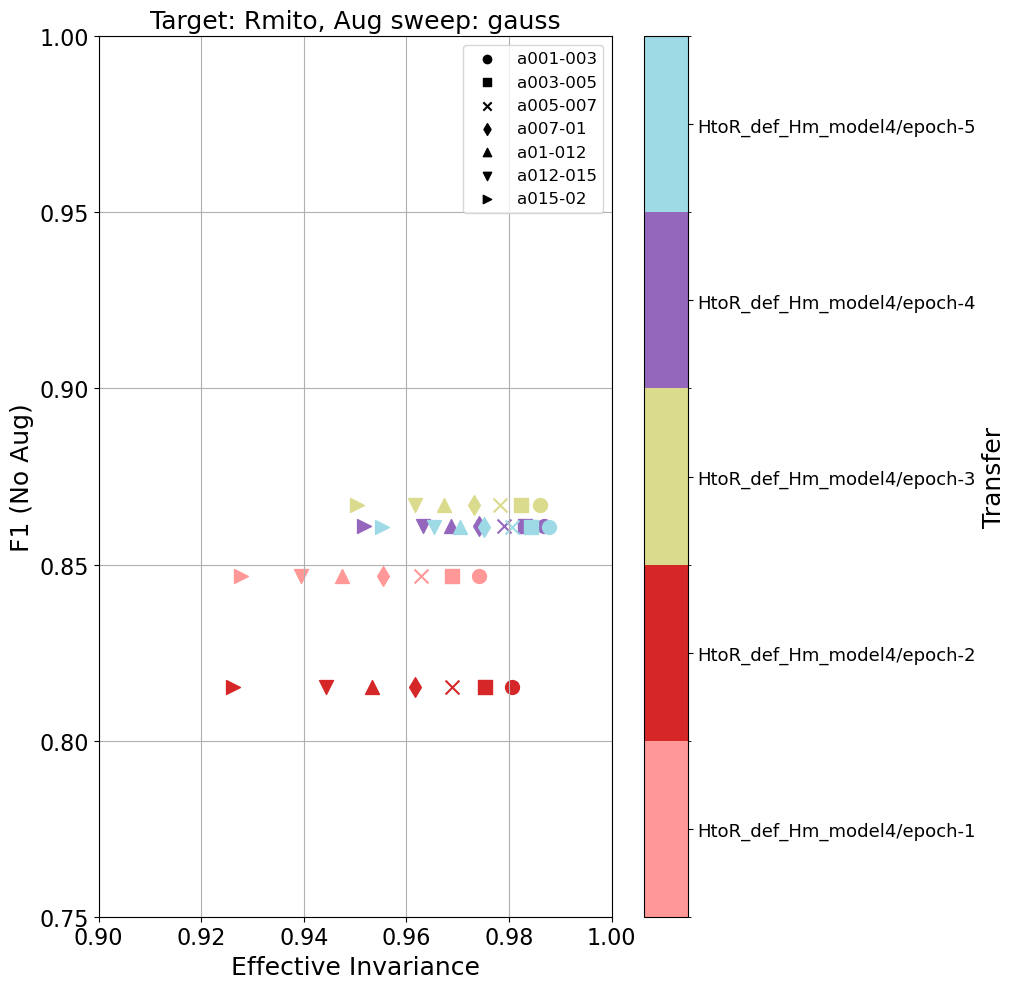

In [30]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0.9, 1),
        ylim=(0.75, 1),
        n_rows=1,
        n_cols = 1,
    )

In [31]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"Gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

Gauss: a001-003
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.2     0.83    0.5        0.49  0.54     0.35
Gauss: a003-005
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.2     0.79    0.5        0.46  0.59      0.3
Gauss: a005-007
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.2     0.85    0.5        0.47  0.64     0.25
Gauss: a007-01
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.2     0.83    0.5        0.47  0.67     0.22
Gauss: a01-012
               kt  kt pval  s rho  s rho pval   pr  pr pval
Task targets                                               
Mito Rmito    0.2     0.88    0.5        0.49  0.7     0.19
Gauss: a01

In [32]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["Hmito", "Rmito"]
    else:
        sources = ["Hmito"]
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    for model_type in source_model_types:
        # if "Unetr" in model_type["EPFL"]:
        #     sources = ["EPFL", "Hmito", "Rmito"]

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_bckg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_bckg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
        
    
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 20.95it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 16.04it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 18.86it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 23.08it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 22.54it/s]


In [33]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
    perturbation_key="gauss",
)

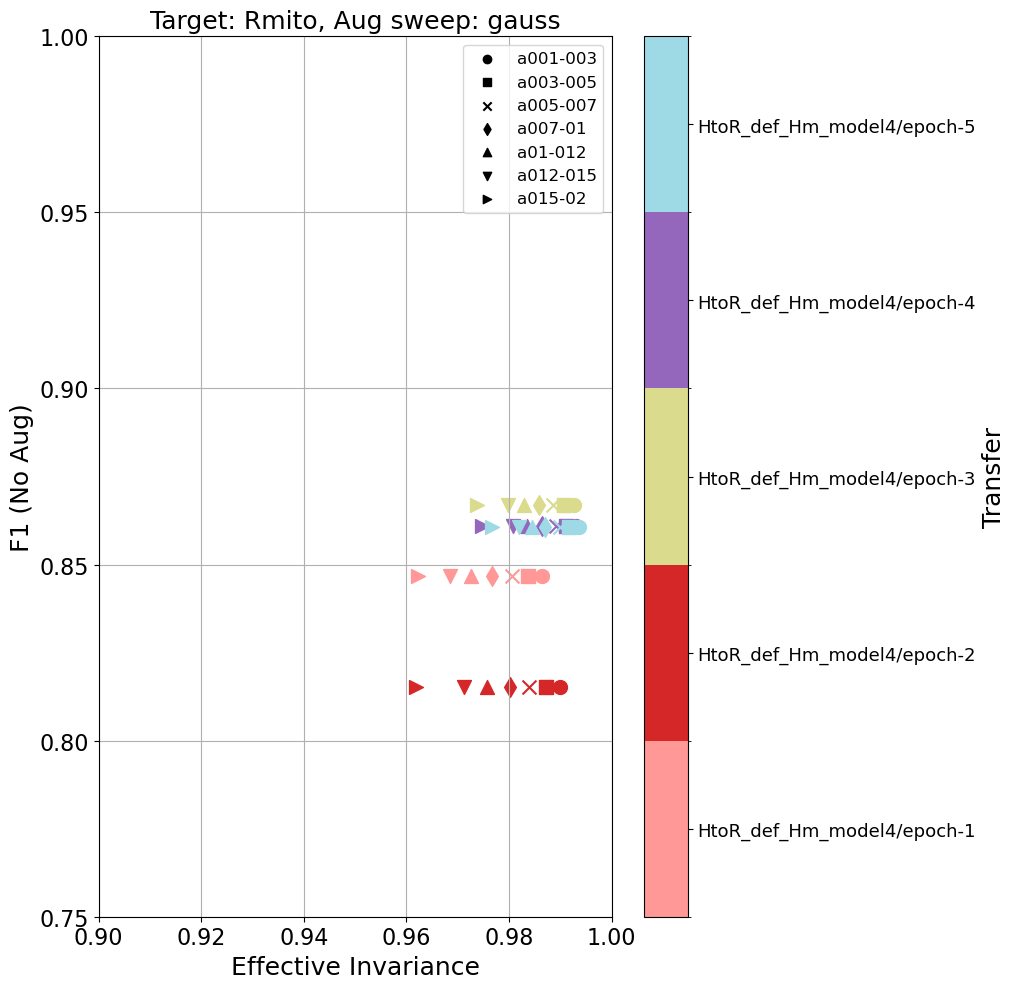

In [34]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0.9, 1),
        ylim=(0.75, 1),
        n_rows=1,
        n_cols = 1,
    )

In [35]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_cmb_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"Gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

Gauss: a001-003
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.2     0.83    0.5        0.47  0.53     0.36
Gauss: a003-005
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.2     0.82    0.5        0.42  0.58     0.31
Gauss: a005-007
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.2     0.84    0.5        0.44  0.63     0.26
Gauss: a007-01
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.2     0.79    0.5        0.45  0.65     0.23
Gauss: a01-012
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.2     0.78    0.5        0.41  0.69      0.2
Gauss: 

In [20]:
per_target_consistency_a001_a003: Dict[str, Dict[str,float]] = {}
per_target_consistency_a003_a005: Dict[str, Dict[str,float]] = {}
per_target_consistency_a005_a007: Dict[str, Dict[str,float]] = {}
per_target_consistency_a007_a01: Dict[str, Dict[str,float]] = {}
per_target_consistency_a01_a02: Dict[str, Dict[str,float]] = {}
for target, per_model_consistency in per_target_cmb_consistency.items():
    per_target_consistency_a001_a003[target] = {}
    per_target_consistency_a003_a005[target] = {}
    per_target_consistency_a005_a007[target] = {}
    per_target_consistency_a007_a01[target] = {}
    per_target_consistency_a01_a02[target] = {}
    for model, consistency in per_model_consistency.items():
        per_target_consistency_a001_a003[target][model] = consistency['norm_Normalize']['gauss'][0]
        per_target_consistency_a003_a005[target][model] = consistency['norm_Normalize']['gauss'][1]
        per_target_consistency_a005_a007[target][model] = consistency['norm_Normalize']['gauss'][2]
        per_target_consistency_a007_a01[target][model] = consistency['norm_Normalize']['gauss'][3]
        per_target_consistency_a01_a02[target][model] = consistency['norm_Normalize']['gauss'][4]


In [ ]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_Normalize']
        else:
            per_target_performance[target][model] = performance


{'EPFL': {'E_model_NA2': 0.8867508172988892, 'Hm_model_NA2': 0.6937870979309082, 'Rm_model_NA2': 0.10001395642757416, 'V_model_NA2': 0.6054315567016602, 'E_model_Res1': 0.9407505989074707, 'Hm_model_Res1': 0.8338801860809326, 'Rm_model_Res1': 0.032384369522333145, 'V_model_Res1': 0.4776468276977539, 'E_model5': 0.9456775188446045, 'Hm_model4': 0.7714987993240356, 'Rm_model4': 0.3006330728530884, 'V_model2': 0.14098334312438965, 'E_model_Unetr2': 0.9188569784164429, 'Hm_model_Unetr2': 0.8077123761177063, 'Rm_model_Unetr2': 0.5673959255218506}, 'Hmito': {'E_model_NA2': 0.0, 'Hm_model_NA2': 0.8956153392791748, 'Rm_model_NA2': 0.18514545261859894, 'V_model_NA2': 0.44375935196876526, 'E_model_Res1': 0.21338218450546265, 'Hm_model_Res1': 0.918044924736023, 'Rm_model_Res1': 0.7860790491104126, 'V_model_Res1': 0.4841475486755371, 'E_model5': 0.385945588350296, 'Hm_model4': 0.9164259433746338, 'Rm_model4': 0.6027390956878662, 'V_model2': 0.6169933080673218, 'E_model_Unetr2': 0.3249965310096741,

In [22]:
per_target_consistency_a001_a003["EPFL"]

{'E_model_NA2': 0.9664643704891205,
 'Hm_model_NA2': 0.9024463891983032,
 'Rm_model_NA2': 0.8236640095710754,
 'V_model_NA2': 0.8753637671470642,
 'E_model_Res1': 0.9735954701900482,
 'Hm_model_Res1': 0.9625447988510132,
 'Rm_model_Res1': 0.894191712141037,
 'V_model_Res1': 0.8751670718193054,
 'E_model5': 0.9732376039028168,
 'Hm_model4': 0.9374893307685852,
 'Rm_model4': 0.7986881732940674,
 'V_model2': 0.7839025259017944,
 'E_model_Unetr2': 0.9449626505374908,
 'Hm_model_Unetr2': 0.9327114224433899,
 'Rm_model_Unetr2': 0.8218412399291992}

In [ ]:
# import json
# import os
# from model_ranking import convert_numpy_types
# save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results"
# if not os.path.exists(save_path):
#     os.makedirs(save_path)
# with open(os.path.join(save_path, "transfer_performance_scores.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_performance),
#     }
#     json.dump(results, f, indent=4)